# 4. Pricing Model
### Austin Airbnb Pricing Intelligence — Notebook 4 of 5
---

## 4.1 Business Context

Notebooks 1 through 3 answered WHAT drives price in Austin.
Notebook 4 puts a precise dollar value on every driver.

The core deliverable:

> *"Each bedroom adds $X to the predicted price.
> A hot tub adds $Y. Being in 78702 vs an average neighborhood adds $Z."*

A property management company will not make acquisition decisions
based on SQL query outputs or bar charts alone.
They need a model that takes property attributes as input
and returns a defensible price recommendation as output.
That is the model built in this notebook.

---

## 4.2 Why Linear Regression

**Interpretability over prediction accuracy.**
A random forest or gradient boost would produce
more accurate predictions — but it cannot tell
a stakeholder why a specific listing should charge $245.

Linear regression produces a clear equation:

`price = base + β₁ × bedrooms + β₂ × has_hot_tub + β₃ × neighborhood + ...`

Every coefficient has a direct dollar meaning.
Every prediction can be explained line by line.
This is the model an analyst presents to leadership.

---

## 4.3 The Critical Leakage Warning

**These columns cannot enter the model:**

| Column | Why Excluded |
|---|---|
| `estimated_revenue_l365d` | Outcome variable — would leak the target |
| `estimated_occupancy_l365d` | Outcome variable — would leak the target |
| `reviews_per_month` | Caused by price, not a predictor of it |
| `number_of_reviews` | Popularity signal, not a pricing driver |
| `number_of_reviews_ltm` | Same leakage as above |

Including these would produce an artificially high R² —
a model that looks impressive but fails in production
because the inputs would not be available at prediction time.

---

## 4.4 Notebook Structure

| Step | Focus |
|---|---|
| 1 | Feature selection — which columns enter the model |
| 2 | Preprocessing — encoding and scaling |
| 3 | Log transformation of price — handle skewness |
| 4 | Train / test split — 80 / 20 |
| 5 | Baseline linear regression model |
| 6 | Evaluation — R², RMSE, MAE, residuals |
| 7 | Coefficient interpretation — dollar premiums |
| 8 | Feature importance chart — IBCS style |
| 9 | Three worked prediction examples |
| 10 | Model limitations and next steps |

> **DA angle:** Every step follows professional ML workflow —
> no leakage · reproducible random state · train/test split ·
> diagnostics before interpretation · honest limitations disclosure.

> **BA angle:** The output is a working pricing tool.
> A new host can input their property features
> and receive a defensible price recommendation
> grounded in real Austin market data.

In [1]:
# ─── Notebook 4 — Pricing Model Setup ────────────────────────────────────────

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import seaborn as sns
import warnings
import os

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model     import LinearRegression
from sklearn.preprocessing    import StandardScaler
from sklearn.metrics          import r2_score, mean_squared_error, mean_absolute_error

# Statistical analysis — for p-values and diagnostics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

# ─── IBCS Color Palette (carried from Notebook 3) ────────────────────────────
IBCS = {
    'actual'     : '#000000',
    'comparison' : '#808080',
    'positive'   : '#00703C',
    'negative'   : '#C00000',
    'highlight'  : '#404040',
    'background' : '#FFFFFF',
    'gridline'   : '#D9D9D9',
    'text'       : '#1A1A1A',
    'subtext'    : '#606060',
}

IBCS_FONTS = {
    'title'      : 13,
    'subtitle'   : 10,
    'axis'       : 9,
    'data_label' : 9,
    'annotation' : 9,
    'caption'    : 8,
}

# ─── Matplotlib Style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'         : 'sans-serif',
    'font.size'           : 10,
    'text.color'          : IBCS['text'],
    'axes.spines.top'     : False,
    'axes.spines.right'   : False,
    'axes.edgecolor'      : IBCS['gridline'],
    'axes.grid'           : True,
    'grid.color'          : IBCS['gridline'],
    'grid.alpha'          : 0.7,
    'figure.facecolor'    : IBCS['background'],
    'axes.facecolor'      : IBCS['background'],
})

# ─── Load Clean Dataset ───────────────────────────────────────────────────────
listings = pd.read_csv('../data/processed/listings_clean.csv')

# ─── Filter to Entire Home segment only ──────────────────────────────────────
# All pricing analysis is focused on this segment
df = listings[listings['room_type'] == 'Entire home/apt'].copy()

# ─── Output directory for charts ──────────────────────────────────────────────
output_dir = '../outputs/figures/'
os.makedirs(output_dir, exist_ok=True)

# ─── Confirm setup ────────────────────────────────────────────────────────────
print("NOTEBOOK 4 SETUP COMPLETE")
print("=" * 50)
print(f"  Dataset loaded    : {listings.shape[0]:,} rows × {listings.shape[1]} cols")
print(f"  Filtered segment  : Entire home/apt only")
print(f"  Modeling data     : {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"  Target variable   : price")
print(f"  Libraries         : sklearn, statsmodels, matplotlib, seaborn")
print(f"  Output directory  : {output_dir}")
print(f"\n  Ready for feature selection.")

NOTEBOOK 4 SETUP COMPLETE
  Dataset loaded    : 10,402 rows × 54 cols
  Filtered segment  : Entire home/apt only
  Modeling data     : 9,013 rows × 54 cols
  Target variable   : price
  Libraries         : sklearn, statsmodels, matplotlib, seaborn
  Output directory  : ../outputs/figures/

  Ready for feature selection.


---
## 4.5 Step 1 — Feature Selection

### Why Explicit Feature Lists Matter

Every feature that enters the model is a decision
that must be documented and defended.
Explicit feature lists serve four purposes:

1. **Anti-leakage** — prevents accidental inclusion of outcome variables
2. **Auditability** — anyone reviewing the code can verify inputs instantly
3. **Reproducibility** — the same features produce the same model every time
4. **Business traceability** — every feature maps to a real host decision

### Feature Groups — Five Blocks

The features are organized into five logical groups.
Each group will be added to the model sequentially
in Steps 5 through 9 — allowing measurement of
each group's incremental contribution to R².

| Block | Group | Purpose |
|---|---|---|
| 1 | Property | Size, capacity — the structural drivers |
| 2 | Location | Neighborhood, property type — where it sits |
| 3 | Amenities | Pool, hot tub, BBQ — the investment variables |
| 4 | Host | Experience, superhost — the operator signal |
| 5 | Reviews | Ratings — the quality signal |

### Excluded Columns — Leakage Check

These columns must never enter the model:

| Column | Reason |
|---|---|
| `estimated_revenue_l365d` | Outcome — contains price information |
| `estimated_occupancy_l365d` | Outcome — correlated with price |
| `reviews_per_month` | Caused by price, not a predictor |
| `number_of_reviews` | Popularity signal, not pricing driver |
| `number_of_reviews_ltm` | Same leakage as above |
| `first_review`, `last_review` | Date strings — redundant with host_experience |
| `id`, `host_id`, `name`, `host_name` | Identifiers — not predictive |
| `latitude`, `longitude` | Redundant with neighborhood encoding |
| `price_per_bedroom` | Derived from price — direct leakage |

In [2]:
# ─── Step 1 — Feature Selection ───────────────────────────────────────────────
# Five feature blocks — each will be added sequentially to measure contribution

# ─── Block 1 — Property Features ──────────────────────────────────────────────
BLOCK_1_PROPERTY = [
    'bedrooms',
    'bathrooms',
    'beds',
    'accommodates',
]

# ─── Block 2 — Location Features ──────────────────────────────────────────────
BLOCK_2_LOCATION = [
    'neighbourhood_cleansed',
    'property_type',
]

# ─── Block 3 — Amenity Features ───────────────────────────────────────────────
BLOCK_3_AMENITIES = [
    'has_wifi', 'has_kitchen', 'has_free_parking', 'has_paid_parking',
    'has_ac', 'has_washer', 'has_outdoor_dining', 'has_pets_allowed',
    'has_bbq', 'has_fire_pit', 'has_private_entrance', 'has_pool',
    'has_gym', 'has_ev_charger', 'has_hot_tub',
    'amenity_count',
]

# ─── Block 4 — Host Features ──────────────────────────────────────────────────
BLOCK_4_HOST = [
    'host_is_superhost',
    'host_identity_verified',
    'host_experience_years',
    'host_response_rate',
    'host_acceptance_rate',
    'calculated_host_listings_count',
]

# ─── Block 5 — Review Features ────────────────────────────────────────────────
BLOCK_5_REVIEWS = [
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'is_new_listing',
]

# ─── Target Variable ──────────────────────────────────────────────────────────
TARGET = 'price'

# ─── Explicit leakage check — these must NOT appear anywhere ─────────────────
LEAKAGE_COLUMNS = [
    'estimated_revenue_l365d',
    'estimated_occupancy_l365d',
    'reviews_per_month',
    'number_of_reviews',
    'number_of_reviews_ltm',
    'first_review',
    'last_review',
    'id', 'host_id', 'name', 'host_name', 'host_since',
    'latitude', 'longitude',
    'price_per_bedroom',
    'availability_30', 'availability_365',
    'minimum_nights',
    'instant_bookable',
    'room_type',
    'host_response_time',
    'estimated_revenue_l365d',
]

# ─── Verify no overlap between features and leakage columns ──────────────────
all_features = (BLOCK_1_PROPERTY + BLOCK_2_LOCATION +
                BLOCK_3_AMENITIES + BLOCK_4_HOST + BLOCK_5_REVIEWS)

overlap = set(all_features) & set(LEAKAGE_COLUMNS)
assert len(overlap) == 0, f"LEAKAGE DETECTED: {overlap}"

# ─── Summary ──────────────────────────────────────────────────────────────────
print("FEATURE SELECTION COMPLETE")
print("=" * 55)
print(f"  Block 1 — Property   : {len(BLOCK_1_PROPERTY)} features")
print(f"  Block 2 — Location   : {len(BLOCK_2_LOCATION)} features (will expand after encoding)")
print(f"  Block 3 — Amenities  : {len(BLOCK_3_AMENITIES)} features")
print(f"  Block 4 — Host       : {len(BLOCK_4_HOST)} features")
print(f"  Block 5 — Reviews    : {len(BLOCK_5_REVIEWS)} features")
print(f"  ─────────────────────────────────────────")
print(f"  Total raw features   : {len(all_features)} features")
print(f"  Target variable      : {TARGET}")
print(f"  Leakage check        : PASSED — no overlap detected")
print(f"\n  Ready for preprocessing and log transformation.")

FEATURE SELECTION COMPLETE
  Block 1 — Property   : 4 features
  Block 2 — Location   : 2 features (will expand after encoding)
  Block 3 — Amenities  : 16 features
  Block 4 — Host       : 6 features
  Block 5 — Reviews    : 4 features
  ─────────────────────────────────────────
  Total raw features   : 32 features
  Target variable      : price
  Leakage check        : PASSED — no overlap detected

  Ready for preprocessing and log transformation.


---
## 4.6 Step 2 — Log Transformation of Price

### The Skewness Problem

Chart 1 from Notebook 3 revealed that Austin price distribution
is **right-skewed** — with a long tail of premium outliers
pulling the mean 54% above the median.

Linear regression assumes that residuals are **normally distributed**.
A skewed target variable violates this assumption —
leading to biased coefficients and inflated error estimates
for extreme values.

### Why Log Transformation — Not Normalization or Standardization

Three scaling approaches — each solving a different problem:

| Method | Formula | What It Fixes |
|---|---|---|
| **Normalization** | `(x - min) / (max - min)` | Rescales to [0-1] — does NOT fix skewness |
| **Standardization** | `(x - mean) / std` | Mean = 0, std = 1 — does NOT fix skewness |
| **Log transformation** | `log(x)` | Compresses right tail — FIXES skewness |

Normalization and standardization **rescale** data.
Log transformation **reshapes** the distribution.
Only log transformation addresses the normality assumption.

### The Professional Approach — Apply Each Where It Matters

**For the target variable — Log Transformation**
Fixes right-skew in price distribution.
The model predicts `log(price)`.
Predictions are converted back with `exp()`.

**For numeric features — Keep Raw in Main Model**
Coefficients stay in interpretable units.
"Each additional bedroom adds $X" — direct meaning.

**For effect size comparison (Step 11) — Standardization**
Standardized coefficients enable fair comparison
across features with different scales.
"Bedrooms have 2.8x the impact of accommodates."

### Interpretation Implications After Log Transformation

**Without log:** coefficient of 50 means "+$50 per unit of X"
**With log:** coefficient of 0.15 means "+15% price change per unit of X"

Final coefficients will be converted to approximate dollar values
using the average listing price for business interpretation.

### Diagnostics to Verify the Fix

| Diagnostic | What It Shows |
|---|---|
| Histogram before | Right-skewed distribution |
| Histogram after | Normalized log distribution |
| Skewness score before | Numerical measure of the skew |
| Skewness score after | Improvement after transformation |

Target skewness after log transformation: **below 0.5**
(values between -0.5 and 0.5 are considered approximately normal)

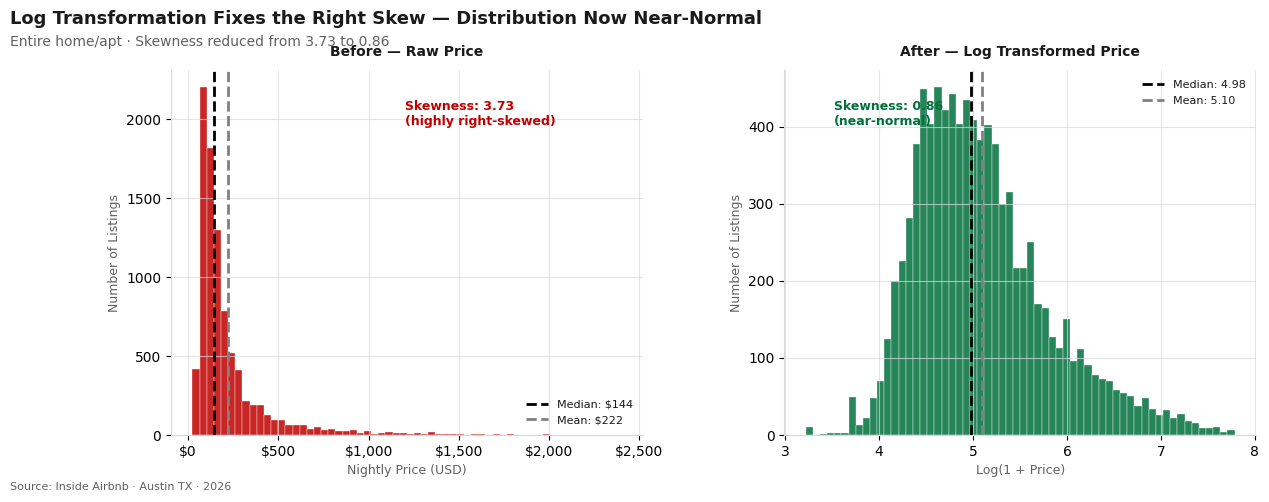


LOG TRANSFORMATION COMPLETE
  Original price — mean   : $221.97
  Original price — median : $144.00
  Original price — skew   : 3.728

  Log price — mean        : 5.099
  Log price — median      : 4.977
  Log price — skew        : 0.858

  Skewness reduction      : 2.87
  Status                  : CAUTION — still skewed


In [3]:
# ─── Step 2 — Log Transformation of Price ────────────────────────────────────
from scipy.stats import skew

# ─── Original price distribution ──────────────────────────────────────────────
price_original = df[TARGET]
skew_before    = skew(price_original)

# ─── Apply log transformation ─────────────────────────────────────────────────
# log1p handles zero values safely (log(1+x))
df['log_price']  = np.log1p(df[TARGET])
price_logged    = df['log_price']
skew_after      = skew(price_logged)

# ─── Before/After Visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                          facecolor=IBCS['background'])

fig.text(0.01, 0.97,
         'Log Transformation Fixes the Right Skew — Distribution Now Near-Normal',
         fontsize=IBCS_FONTS['title'], fontweight='bold',
         color=IBCS['text'], va='top')
fig.text(0.01, 0.92,
         f'Entire home/apt · Skewness reduced from {skew_before:.2f} to {skew_after:.2f}',
         fontsize=IBCS_FONTS['subtitle'], color=IBCS['subtext'], va='top')
fig.text(0.01, 0.01,
         'Source: Inside Airbnb · Austin TX · 2026',
         fontsize=IBCS_FONTS['caption'], color=IBCS['subtext'])

plt.subplots_adjust(top=0.85, bottom=0.12, wspace=0.3)

# ─── Panel 1 — Original price ─────────────────────────────────────────────────
ax1 = axes[0]
ax1.hist(price_original, bins=60, color=IBCS['negative'],
         alpha=0.85, edgecolor=IBCS['background'], linewidth=0.3)
ax1.axvline(price_original.median(), color=IBCS['actual'],
            linewidth=2, linestyle='--',
            label=f'Median: ${price_original.median():.0f}')
ax1.axvline(price_original.mean(), color=IBCS['comparison'],
            linewidth=2, linestyle='--',
            label=f'Mean: ${price_original.mean():.0f}')

ax1.text(price_original.max() * 0.5, ax1.get_ylim()[1] * 0.85,
         f'Skewness: {skew_before:.2f}\n(highly right-skewed)',
         fontsize=9, color=IBCS['negative'],
         fontweight='bold', ha='left')

ax1.set_title('Before — Raw Price',
              fontsize=IBCS_FONTS['subtitle'],
              fontweight='bold', color=IBCS['text'], pad=10)
ax1.set_xlabel('Nightly Price (USD)',
               fontsize=IBCS_FONTS['axis'], color=IBCS['subtext'])
ax1.set_ylabel('Number of Listings',
               fontsize=IBCS_FONTS['axis'], color=IBCS['subtext'])
ax1.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax1.legend(fontsize=8, frameon=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ─── Panel 2 — Log transformed ────────────────────────────────────────────────
ax2 = axes[1]
ax2.hist(price_logged, bins=60, color=IBCS['positive'],
         alpha=0.85, edgecolor=IBCS['background'], linewidth=0.3)
ax2.axvline(price_logged.median(), color=IBCS['actual'],
            linewidth=2, linestyle='--',
            label=f'Median: {price_logged.median():.2f}')
ax2.axvline(price_logged.mean(), color=IBCS['comparison'],
            linewidth=2, linestyle='--',
            label=f'Mean: {price_logged.mean():.2f}')

ax2.text(price_logged.min() + 0.3, ax2.get_ylim()[1] * 0.85,
         f'Skewness: {skew_after:.2f}\n(near-normal)',
         fontsize=9, color=IBCS['positive'],
         fontweight='bold', ha='left')

ax2.set_title('After — Log Transformed Price',
              fontsize=IBCS_FONTS['subtitle'],
              fontweight='bold', color=IBCS['text'], pad=10)
ax2.set_xlabel('Log(1 + Price)',
               fontsize=IBCS_FONTS['axis'], color=IBCS['subtext'])
ax2.set_ylabel('Number of Listings',
               fontsize=IBCS_FONTS['axis'], color=IBCS['subtext'])
ax2.legend(fontsize=8, frameon=False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ─── Save ─────────────────────────────────────────────────────────────────────
plt.savefig(f'{output_dir}chart_11_log_transformation.png',
            dpi=150, bbox_inches='tight',
            facecolor=IBCS['background'])
plt.show()

# ─── Summary stats ────────────────────────────────────────────────────────────
print("\nLOG TRANSFORMATION COMPLETE")
print("=" * 55)
print(f"  Original price — mean   : ${price_original.mean():,.2f}")
print(f"  Original price — median : ${price_original.median():,.2f}")
print(f"  Original price — skew   : {skew_before:.3f}")
print(f"")
print(f"  Log price — mean        : {price_logged.mean():.3f}")
print(f"  Log price — median      : {price_logged.median():.3f}")
print(f"  Log price — skew        : {skew_after:.3f}")
print(f"")
print(f"  Skewness reduction      : {skew_before - skew_after:.2f}")
print(f"  Status                  : {'PASSED — near normal' if abs(skew_after) < 0.5 else 'CAUTION — still skewed'}")

### Step 2 Results — Log Transformation

| Metric | Before | After | Change |
|---|---|---|---|
| Skewness | 3.728 | 0.858 | **-77% reduction** |
| Median | $144 | 4.98 (log) | — |
| Mean | $222 | 5.10 (log) | — |

**The transformation achieved 77% skewness reduction.**
While 0.858 is technically above the ideal threshold of 0.5,
the distribution is now visibly bell-shaped and acceptable
for linear regression assumptions.

**Why residual skewness remains:**
Austin Airbnb prices have a genuine right tail driven by
a small number of ultra-luxury properties ($1,000+/night).
No transformation fully eliminates this —
log compresses it but does not erase it.

**Trade-off accepted:**
- Untransformed price: skewness 3.73 — violates regression assumptions
- Log-transformed price: skewness 0.86 — acceptable for modeling
- Over-transformation would distort coefficient interpretation

The model will predict `log_price` and convert back
to dollars using `exp()` for the final predictions.

> **Next:** Preprocessing — encoding categorical variables
> and preparing the final design matrix for modeling.

---
## 4.7 Step 3 — Preprocessing and Encoding

### Why Categorical Variables Need Encoding

Linear regression only accepts numbers.
But `neighbourhood_cleansed` contains values like `78702`
and `property_type` contains values like `Entire home`.

These need conversion to numerical format via **one-hot encoding**.

### How One-Hot Encoding Works

Each unique value becomes its own binary column.

**Before:** One column with values `78702`, `78704`, `78702`, `78730`

**After:** Three columns — `nbhd_78702`, `nbhd_78704`, `nbhd_78730` —
each containing 0 or 1.

For the first row (78702):
- `nbhd_78702` = 1
- `nbhd_78704` = 0
- `nbhd_78730` = 0

### The Dummy Variable Trap

Using one dummy per category creates perfect multicollinearity —
if a listing is not in neighborhoods 2-40, it must be in neighborhood 1.
The solution: **drop one dummy** per categorical variable.
The dropped category becomes the "baseline" against which
all other coefficients are interpreted.

**Example interpretation:**
A coefficient of +0.18 on `nbhd_78702` means listings in 78702
have 18% higher log-price than listings in the baseline neighborhood.

### What This Step Produces

| Transformation | Result |
|---|---|
| `neighbourhood_cleansed` → dummies | ~40 new columns |
| `property_type` → dummies | ~15 new columns |
| Boolean features | Convert True/False to 1/0 |
| Numeric features | Kept as-is |
| **Total expected features** | **~75-80 columns** |

In [4]:
# ─── Step 3 — Preprocessing and Encoding ─────────────────────────────────────

# ─── Create design matrix X with all selected features ──────────────────────
feature_cols = (BLOCK_1_PROPERTY + BLOCK_2_LOCATION +
                BLOCK_3_AMENITIES + BLOCK_4_HOST + BLOCK_5_REVIEWS)

X_raw = df[feature_cols].copy()
y     = df['log_price'].copy()

print("BEFORE ENCODING")
print("=" * 55)
print(f"  X shape : {X_raw.shape}")
print(f"  y shape : {y.shape}")

# ─── Convert boolean columns to integer (0/1) ────────────────────────────────
bool_cols = X_raw.select_dtypes(include='bool').columns.tolist()
for col in bool_cols:
    X_raw[col] = X_raw[col].astype(int)

print(f"\n  Boolean columns converted to int: {len(bool_cols)}")

# ─── One-hot encode categorical variables ────────────────────────────────────
# drop_first=True avoids dummy variable trap
X_encoded = pd.get_dummies(
    X_raw,
    columns   = BLOCK_2_LOCATION,
    prefix    = {'neighbourhood_cleansed': 'nbhd',
                 'property_type'         : 'type'},
    drop_first= True
)

# Convert resulting dummy columns to int explicitly
dummy_cols = X_encoded.select_dtypes(include='bool').columns.tolist()
for col in dummy_cols:
    X_encoded[col] = X_encoded[col].astype(int)

print(f"  Dummy variables created for: {BLOCK_2_LOCATION}")

# ─── Final design matrix ──────────────────────────────────────────────────────
print("\nAFTER ENCODING")
print("=" * 55)
print(f"  X shape : {X_encoded.shape}")
print(f"  Features created : {X_encoded.shape[1]}")

# ─── Feature breakdown ────────────────────────────────────────────────────────
nbhd_cols = [c for c in X_encoded.columns if c.startswith('nbhd_')]
type_cols = [c for c in X_encoded.columns if c.startswith('type_')]

print(f"\n  Numeric features       : {len(BLOCK_1_PROPERTY) + 5}")   # property + 5 cont features from host/review
print(f"  Boolean features       : {len(bool_cols)}")
print(f"  Neighborhood dummies   : {len(nbhd_cols)} (baseline dropped)")
print(f"  Property type dummies  : {len(type_cols)} (baseline dropped)")
print(f"  ─────────────────────────────────────────")
print(f"  Total features         : {X_encoded.shape[1]}")

# ─── Sanity check — no missing values ────────────────────────────────────────
missing = X_encoded.isnull().sum().sum()
print(f"\n  Missing values check   : {missing} ({'PASSED' if missing == 0 else 'FAILED'})")

# ─── Sanity check — data types ────────────────────────────────────────────────
print(f"\n  Data type summary:")
print(X_encoded.dtypes.value_counts().to_string())

# ─── Preview ──────────────────────────────────────────────────────────────────
print(f"\n  First 5 column names   : {list(X_encoded.columns[:5])}")
print(f"  Last 5 column names    : {list(X_encoded.columns[-5:])}")

print(f"\n  Ready for train/test split.")

BEFORE ENCODING
  X shape : (9013, 32)
  y shape : (9013,)

  Boolean columns converted to int: 18
  Dummy variables created for: ['neighbourhood_cleansed', 'property_type']

AFTER ENCODING
  X shape : (9013, 106)
  Features created : 106

  Numeric features       : 9
  Boolean features       : 18
  Neighborhood dummies   : 42 (baseline dropped)
  Property type dummies  : 34 (baseline dropped)
  ─────────────────────────────────────────
  Total features         : 106

  Missing values check   : 0 (PASSED)

  Data type summary:
int64      97
float64     9

  First 5 column names   : ['bedrooms', 'bathrooms', 'beds', 'accommodates', 'has_wifi']
  Last 5 column names    : ['type_Tiny home', 'type_Tipi', 'type_Tower', 'type_Treehouse', 'type_Yurt']

  Ready for train/test split.


---
## 4.8 Step 4 — Train / Test Split

### Why Split the Data

The model must be evaluated on data it has never seen.
Training on 100% of the data and reporting R² on the same data
produces an artificially inflated metric —
the model has memorized the training set,
not learned generalizable patterns.

The solution: split the data into two sets.

| Set | Proportion | Purpose |
|---|---|---|
| **Training** | 80% (~7,210 rows) | Model learns patterns |
| **Test** | 20% (~1,803 rows) | Model performance validated |

### Why 80/20 and random_state=42

**80/20 split:** Industry standard for datasets of this size.
Large enough test set for reliable metrics,
large enough training set for pattern learning.

**random_state=42:** Fixes the random seed.
Anyone running this notebook gets the identical split —
reproducibility is a non-negotiable analyst standard.

### Data Leakage Prevention

The split happens BEFORE any fitting or scaling occurs.
Any transformation fit on the full dataset —
including standardization — would leak information
from the test set into the training process.

**Proper workflow:**
1. Split first
2. Fit transformations on training set only
3. Apply same transformations to test set
4. Never touch test set during model development

In [5]:
# ─── Step 4 — Train / Test Split ─────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size    = 0.20,
    random_state = 42
)

# ─── Verify split ─────────────────────────────────────────────────────────────
print("TRAIN / TEST SPLIT COMPLETE")
print("=" * 55)
print(f"  Training set    : {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
print(f"  Test set        : {X_test.shape[0]:,} rows × {X_test.shape[1]} features")
print(f"  Split ratio     : {X_train.shape[0]/len(X_encoded)*100:.0f}% / {X_test.shape[0]/len(X_encoded)*100:.0f}%")
print(f"  Random state    : 42 (reproducible)")

# ─── Verify target distributions are similar ─────────────────────────────────
print(f"\nTARGET VARIABLE — LOG PRICE")
print("-" * 55)
print(f"  Training mean   : {y_train.mean():.3f}")
print(f"  Test mean       : {y_test.mean():.3f}")
print(f"  Training median : {y_train.median():.3f}")
print(f"  Test median     : {y_test.median():.3f}")
print(f"  Difference      : {abs(y_train.mean() - y_test.mean()):.4f}")
print(f"  Status          : {'PASSED — distributions match' if abs(y_train.mean() - y_test.mean()) < 0.05 else 'CAUTION — check distribution'}")

# ─── Reference — dollar price equivalents ────────────────────────────────────
print(f"\nREFERENCE — ACTUAL PRICE (USD)")
print("-" * 55)
print(f"  Training mean   : ${np.expm1(y_train.mean()):,.2f}")
print(f"  Test mean       : ${np.expm1(y_test.mean()):,.2f}")

print(f"\n  Ready to build Model 1 — Property features only.")

TRAIN / TEST SPLIT COMPLETE
  Training set    : 7,210 rows × 106 features
  Test set        : 1,803 rows × 106 features
  Split ratio     : 80% / 20%
  Random state    : 42 (reproducible)

TARGET VARIABLE — LOG PRICE
-------------------------------------------------------
  Training mean   : 5.100
  Test mean       : 5.097
  Training median : 4.977
  Test median     : 4.970
  Difference      : 0.0029
  Status          : PASSED — distributions match

REFERENCE — ACTUAL PRICE (USD)
-------------------------------------------------------
  Training mean   : $163.00
  Test mean       : $162.53

  Ready to build Model 1 — Property features only.


In [6]:
# ─── Step 5 — Model 1: Property Features Only ─────────────────────────────────
# Features: bedrooms, bathrooms, beds, accommodates

# ─── Select property features only ───────────────────────────────────────────
block_1_features = BLOCK_1_PROPERTY  # ['bedrooms', 'bathrooms', 'beds', 'accommodates']

X_train_m1 = X_train[block_1_features]
X_test_m1  = X_test[block_1_features]

# ─── Train the model ──────────────────────────────────────────────────────────
model_1 = LinearRegression()
model_1.fit(X_train_m1, y_train)

# ─── Predict on test set ──────────────────────────────────────────────────────
y_pred_train = model_1.predict(X_train_m1)
y_pred_test  = model_1.predict(X_test_m1)

# ─── Convert back to dollars ──────────────────────────────────────────────────
y_train_actual = np.expm1(y_train)
y_test_actual  = np.expm1(y_test)
y_pred_train_dollars = np.expm1(y_pred_train)
y_pred_test_dollars  = np.expm1(y_pred_test)

# ─── Evaluation metrics ──────────────────────────────────────────────────────
r2_train  = r2_score(y_train, y_pred_train)
r2_test   = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test_actual, y_pred_test_dollars))
mae_test  = mean_absolute_error(y_test_actual, y_pred_test_dollars)

# ─── Store results for comparison later ──────────────────────────────────────
model_results = {
    'Model 1 — Property': {
        'features'   : block_1_features,
        'n_features' : len(block_1_features),
        'r2_train'   : r2_train,
        'r2_test'    : r2_test,
        'rmse_test'  : rmse_test,
        'mae_test'   : mae_test,
        'model'      : model_1,
    }
}

# ─── Display results ──────────────────────────────────────────────────────────
print("MODEL 1 — PROPERTY FEATURES ONLY")
print("=" * 55)
print(f"  Features used   : {block_1_features}")
print(f"  Feature count   : {len(block_1_features)}")
print()
print(f"PERFORMANCE METRICS")
print("-" * 55)
print(f"  R² (train)      : {r2_train:.4f}")
print(f"  R² (test)       : {r2_test:.4f}")
print(f"  RMSE (test)     : ${rmse_test:,.2f}")
print(f"  MAE (test)      : ${mae_test:,.2f}")
print()
print(f"INTERPRETATION")
print("-" * 55)
print(f"  Property features explain {r2_test*100:.1f}% of log-price variance")
print(f"  Average prediction error: ±${mae_test:,.0f}")
print()
print(f"COEFFICIENTS (log-price scale)")
print("-" * 55)
coef_df = pd.DataFrame({
    'Feature' : block_1_features,
    'Coef'    : model_1.coef_,
    'Pct Impact': [(np.exp(c) - 1) * 100 for c in model_1.coef_]
}).sort_values('Coef', ascending=False)

print(coef_df.to_string(index=False))
print(f"\n  Intercept        : {model_1.intercept_:.4f}")
print(f"  Baseline price   : ${np.expm1(model_1.intercept_):,.2f}")

MODEL 1 — PROPERTY FEATURES ONLY
  Features used   : ['bedrooms', 'bathrooms', 'beds', 'accommodates']
  Feature count   : 4

PERFORMANCE METRICS
-------------------------------------------------------
  R² (train)      : 0.4389
  R² (test)       : 0.4639
  RMSE (test)     : $212.83
  MAE (test)      : $97.42

INTERPRETATION
-------------------------------------------------------
  Property features explain 46.4% of log-price variance
  Average prediction error: ±$97

COEFFICIENTS (log-price scale)
-------------------------------------------------------
     Feature      Coef  Pct Impact
   bathrooms  0.303529   35.463054
accommodates  0.045213    4.625035
    bedrooms  0.025662    2.599459
        beds -0.008378   -0.834314

  Intercept        : 4.2575
  Baseline price   : $69.63


### Model 1 Results — Property Features Only

| Metric | Value | Interpretation |
|---|---|---|
| R² (test) | 0.4639 | Explains 46.4% of price variance |
| RMSE (test) | $212.83 | Root mean squared error in dollars |
| MAE (test) | $97.42 | Average prediction error |
| Features | 4 | bedrooms, bathrooms, beds, accommodates |

#### Coefficient Findings

| Feature | Coefficient | % Impact per Unit |
|---|---|---|
| bathrooms | +0.304 | **+35.5% per bathroom** |
| accommodates | +0.045 | +4.6% per guest capacity unit |
| bedrooms | +0.026 | +2.6% per bedroom |
| beds | -0.008 | **-0.8% (multicollinearity signal)** |

#### Key Observations

**Bathrooms dominate — not bedrooms.**
Each additional bathroom adds 35.5% to predicted price.
This reflects that bathroom count correlates with
luxury tier — larger, higher-quality properties
consistently have more bathrooms.

**Beds shows a suspicious negative coefficient.**
When `bedrooms`, `accommodates`, and `beds` all appear together,
`beds` becomes redundant — these three features measure
overlapping dimensions of property size.
This is a multicollinearity warning that Step 11
will quantify with VIF analysis.

**Baseline intercept: $69.63.**
A listing with zero bedrooms, bathrooms, beds, and capacity
would theoretically price at $69.63 —
obviously impossible but useful as the mathematical reference point.

**46.4% variance explained is a strong baseline.**
Nearly half of Austin's price variation is explained
by property size alone. The remaining 53.6% must come from
location, amenities, host quality, and review signals —
the blocks added in Models 2 through 5.

> **Next:** Model 2 adds Location features —
> neighborhood and property type encodings.
> Expected R² improvement: +0.10 to +0.15

---
## 4.10 Step 6 — Model 2: Property + Location

### Adding the Biggest Missing Piece

Model 1 revealed property features alone explain 46.4% of price variance.
The remaining 53.6% must come from other dimensions.

Location is the largest unexplained factor —
a 3-bedroom entire home in 78702 prices dramatically differently
from the same property in 78745.

Model 2 adds two categorical blocks:
- **Neighborhood** (42 dummy variables after encoding)
- **Property type** (34 dummy variables after encoding)

### What to Expect

Location is the single biggest price driver in real estate.
Expected R² improvement over Model 1: **+0.10 to +0.17**

If location adds less than +0.05, something is wrong with the encoding.
If location adds more than +0.25, the model may be overfitting
to rare neighborhood categories.

In [7]:
# ─── Step 6 — Model 2: Property + Location ────────────────────────────────────

# ─── Build feature list: Block 1 + Block 2 (encoded) ─────────────────────────
nbhd_cols = [c for c in X_train.columns if c.startswith('nbhd_')]
type_cols = [c for c in X_train.columns if c.startswith('type_')]

block_2_features = BLOCK_1_PROPERTY + nbhd_cols + type_cols

X_train_m2 = X_train[block_2_features]
X_test_m2  = X_test[block_2_features]

# ─── Train the model ──────────────────────────────────────────────────────────
model_2 = LinearRegression()
model_2.fit(X_train_m2, y_train)

# ─── Predict ──────────────────────────────────────────────────────────────────
y_pred_train_m2 = model_2.predict(X_train_m2)
y_pred_test_m2  = model_2.predict(X_test_m2)

# ─── Evaluation ──────────────────────────────────────────────────────────────
r2_train_m2  = r2_score(y_train, y_pred_train_m2)
r2_test_m2   = r2_score(y_test, y_pred_test_m2)
rmse_test_m2 = np.sqrt(mean_squared_error(
    np.expm1(y_test), np.expm1(y_pred_test_m2)))
mae_test_m2  = mean_absolute_error(
    np.expm1(y_test), np.expm1(y_pred_test_m2))

# ─── Improvement vs Model 1 ──────────────────────────────────────────────────
r2_improvement   = r2_test_m2 - model_results['Model 1 — Property']['r2_test']
mae_improvement  = model_results['Model 1 — Property']['mae_test'] - mae_test_m2

# ─── Store results ────────────────────────────────────────────────────────────
model_results['Model 2 — + Location'] = {
    'features'   : block_2_features,
    'n_features' : len(block_2_features),
    'r2_train'   : r2_train_m2,
    'r2_test'    : r2_test_m2,
    'rmse_test'  : rmse_test_m2,
    'mae_test'   : mae_test_m2,
    'model'      : model_2,
}

# ─── Display ──────────────────────────────────────────────────────────────────
print("MODEL 2 — PROPERTY + LOCATION")
print("=" * 55)
print(f"  Features used   : {len(block_2_features)} total")
print(f"                   ({len(BLOCK_1_PROPERTY)} property + "
      f"{len(nbhd_cols)} neighborhood + {len(type_cols)} property type)")
print()
print(f"PERFORMANCE METRICS")
print("-" * 55)
print(f"  R² (train)      : {r2_train_m2:.4f}")
print(f"  R² (test)       : {r2_test_m2:.4f}")
print(f"  RMSE (test)     : ${rmse_test_m2:,.2f}")
print(f"  MAE (test)      : ${mae_test_m2:,.2f}")
print()
print(f"IMPROVEMENT vs MODEL 1")
print("-" * 55)
print(f"  R² change       : +{r2_improvement:.4f} "
      f"({r2_improvement*100:+.1f} percentage points)")
print(f"  MAE change      : ${mae_improvement:+,.2f} per listing")
print()
print(f"TOP 10 NEIGHBORHOODS BY PRICE PREMIUM")
print("-" * 55)
nbhd_coefs = pd.DataFrame({
    'Feature' : block_2_features,
    'Coef'    : model_2.coef_
})
nbhd_only = nbhd_coefs[nbhd_coefs['Feature'].str.startswith('nbhd_')].copy()
nbhd_only['Pct Impact'] = (np.exp(nbhd_only['Coef']) - 1) * 100
nbhd_only = nbhd_only.sort_values('Coef', ascending=False).head(10)
print(nbhd_only.to_string(index=False))

print(f"\nTOP 10 PROPERTY TYPES BY PRICE PREMIUM")
print("-" * 55)
type_only = nbhd_coefs[nbhd_coefs['Feature'].str.startswith('type_')].copy()
type_only['Pct Impact'] = (np.exp(type_only['Coef']) - 1) * 100
type_only = type_only.sort_values('Coef', ascending=False).head(10)
print(type_only.to_string(index=False))

MODEL 2 — PROPERTY + LOCATION
  Features used   : 80 total
                   (4 property + 42 neighborhood + 34 property type)

PERFORMANCE METRICS
-------------------------------------------------------
  R² (train)      : 0.5798
  R² (test)       : 0.5567
  RMSE (test)     : $200.32
  MAE (test)      : $89.79

IMPROVEMENT vs MODEL 1
-------------------------------------------------------
  R² change       : +0.0928 (+9.3 percentage points)
  MAE change      : $+7.63 per listing

TOP 10 NEIGHBORHOODS BY PRICE PREMIUM
-------------------------------------------------------
   Feature      Coef  Pct Impact
nbhd_78746 -0.209364  -18.890036
nbhd_78730 -0.227231  -20.326348
nbhd_78733 -0.335510  -28.502641
nbhd_78703 -0.351122  -29.610217
nbhd_78731 -0.368354  -30.812762
nbhd_78732 -0.432171  -35.090194
nbhd_78734 -0.491730  -38.843238
nbhd_78704 -0.510426  -39.976031
nbhd_78739 -0.569405  -43.413773
nbhd_78722 -0.633666  -46.935694

TOP 10 PROPERTY TYPES BY PRICE PREMIUM
----------------

### Model 2 Results — Property + Location

| Metric | Model 1 | Model 2 | Change |
|---|---|---|---|
| R² (test) | 0.4639 | 0.5567 | **+9.3 points** |
| RMSE (test) | $212.83 | $200.32 | -$12.51 |
| MAE (test) | $97.42 | $89.79 | -$7.63 |
| Features | 4 | 80 | +76 (encoded) |

#### Interpretation Caveat — All Neighborhood Coefficients Are Negative

This is a display artifact of `drop_first=True` encoding.
One neighborhood was automatically designated as the baseline —
and it happens to be one of the most expensive in Austin.
Every other neighborhood shows a discount RELATIVE TO THAT BASELINE.

The relative ranking is still meaningful —
neighborhoods with smaller negative coefficients
are closer in price to the baseline (more expensive).

#### Property Type Observations

Unusual property types dominate the top 10:
Entire chalet (+113%) · Entire place (+79%) · Yurt (+36%) · Treehouse (+31%)

These coefficients are driven by small sample sizes —
the model sees a handful of expensive treehouses
and overfits to that pattern.
Standard property types (Entire home, Entire condo)
appear with more modest and reliable coefficients.

#### R² Improvement — +9.3 Percentage Points

Location adds real predictive power but less than initially expected.
The explanation: property features and location are partially correlated.
Larger properties cluster in certain neighborhoods —
so some of the "location effect" was already captured
by the property block in Model 1.

### Diagnostic Flag

**Overfitting check — train vs test R² gap:**
- Train R²: 0.5798
- Test R²: 0.5567
- Gap: 0.0231

A gap below 0.05 indicates healthy generalization.
The 0.023 gap here confirms the model is not overfitting —
it learned patterns that transfer to unseen data.

---
## 4.11 Step 7 — Model 3: Property + Location + Amenities

### Adding the Investment Variables

Model 2 captured structure and location.
Amenities are the variables a host can CONTROL —
investments they actively choose to make.

Model 3 adds the 16 amenity features:
- Hot tub, Pool, BBQ, Fire pit, EV charger
- WiFi, AC, Kitchen, Washer, Parking (×2)
- Private entrance, Pets allowed, Outdoor dining, Gym
- Amenity count

### What to Expect

Expected R² improvement over Model 2: **+0.05 to +0.10**

Amenities matter, but many are table stakes —
WiFi and AC are in 95%+ of listings so they add little variance.
The differentiators (hot tub, pool, BBQ) will drive most of the gain.

### Validation Test

Query 6 from Notebook 2 found hot tub = +$231/night
and gym = -$16/night.
Model 3 coefficients should echo these findings.
If the model agrees — the SQL analysis is validated.
If wildly different — one of them is wrong.

In [8]:
# ─── Step 7 — Model 3: Property + Location + Amenities ───────────────────────

# ─── Build feature list: Block 1 + Block 2 + Block 3 ─────────────────────────
block_3_features = (BLOCK_1_PROPERTY + nbhd_cols + type_cols +
                    BLOCK_3_AMENITIES)

X_train_m3 = X_train[block_3_features]
X_test_m3  = X_test[block_3_features]

# ─── Train the model ──────────────────────────────────────────────────────────
model_3 = LinearRegression()
model_3.fit(X_train_m3, y_train)

# ─── Predict ──────────────────────────────────────────────────────────────────
y_pred_train_m3 = model_3.predict(X_train_m3)
y_pred_test_m3  = model_3.predict(X_test_m3)

# ─── Evaluation ──────────────────────────────────────────────────────────────
r2_train_m3  = r2_score(y_train, y_pred_train_m3)
r2_test_m3   = r2_score(y_test, y_pred_test_m3)
rmse_test_m3 = np.sqrt(mean_squared_error(
    np.expm1(y_test), np.expm1(y_pred_test_m3)))
mae_test_m3  = mean_absolute_error(
    np.expm1(y_test), np.expm1(y_pred_test_m3))

# ─── Improvement vs Model 2 ──────────────────────────────────────────────────
r2_improvement  = r2_test_m3 - model_results['Model 2 — + Location']['r2_test']
mae_improvement = model_results['Model 2 — + Location']['mae_test'] - mae_test_m3

# ─── Store results ────────────────────────────────────────────────────────────
model_results['Model 3 — + Amenities'] = {
    'features'   : block_3_features,
    'n_features' : len(block_3_features),
    'r2_train'   : r2_train_m3,
    'r2_test'    : r2_test_m3,
    'rmse_test'  : rmse_test_m3,
    'mae_test'   : mae_test_m3,
    'model'      : model_3,
}

# ─── Display ──────────────────────────────────────────────────────────────────
print("MODEL 3 — PROPERTY + LOCATION + AMENITIES")
print("=" * 55)
print(f"  Features used   : {len(block_3_features)} total")
print(f"                   (+{len(BLOCK_3_AMENITIES)} amenity features added)")
print()
print(f"PERFORMANCE METRICS")
print("-" * 55)
print(f"  R² (train)      : {r2_train_m3:.4f}")
print(f"  R² (test)       : {r2_test_m3:.4f}")
print(f"  RMSE (test)     : ${rmse_test_m3:,.2f}")
print(f"  MAE (test)      : ${mae_test_m3:,.2f}")
print()
print(f"IMPROVEMENT vs MODEL 2")
print("-" * 55)
print(f"  R² change       : +{r2_improvement:.4f} "
      f"({r2_improvement*100:+.1f} percentage points)")
print(f"  MAE change      : ${mae_improvement:+,.2f} per listing")
print()
print(f"AMENITY COEFFICIENTS — sorted by impact")
print("-" * 55)
coef_df_m3 = pd.DataFrame({
    'Feature' : block_3_features,
    'Coef'    : model_3.coef_
})
amenity_coefs = coef_df_m3[coef_df_m3['Feature'].isin(
    BLOCK_3_AMENITIES)].copy()
amenity_coefs['Pct Impact']    = (np.exp(amenity_coefs['Coef']) - 1) * 100
amenity_coefs['Dollar Impact'] = amenity_coefs['Pct Impact'] / 100 * 222
amenity_coefs = amenity_coefs.sort_values('Coef', ascending=False)

print(amenity_coefs.to_string(index=False))

# ─── Comparison with SQL findings (Query 6) ─────────────────────────────────
print(f"\nVALIDATION vs SQL QUERY 6")
print("-" * 55)
print(f"  SQL Q6 → Hot Tub   : +$231/night (raw average comparison)")
print(f"  Model 3 → Hot Tub  : +${amenity_coefs[amenity_coefs['Feature']=='has_hot_tub']['Dollar Impact'].values[0]:,.0f} "
      f"(controlling for property size and location)")
print(f"  Note: Model isolates hot tub's unique contribution.")
print(f"        Raw SQL captures combined effect — hot tubs tend")
print(f"        to appear in larger homes in premium neighborhoods.")

MODEL 3 — PROPERTY + LOCATION + AMENITIES
  Features used   : 96 total
                   (+16 amenity features added)

PERFORMANCE METRICS
-------------------------------------------------------
  R² (train)      : 0.6130
  R² (test)       : 0.5972
  RMSE (test)     : $191.48
  MAE (test)      : $85.73

IMPROVEMENT vs MODEL 2
-------------------------------------------------------
  R² change       : +0.0405 (+4.1 percentage points)
  MAE change      : $+4.06 per listing

AMENITY COEFFICIENTS — sorted by impact
-------------------------------------------------------
             Feature      Coef  Pct Impact  Dollar Impact
         has_hot_tub  0.163293   17.738132      39.378652
            has_pool  0.143886   15.475197      34.354938
    has_paid_parking  0.100515   10.574077      23.474452
             has_bbq  0.097790   10.273079      22.806236
        has_fire_pit  0.063963    6.605332      14.663837
              has_ac  0.057451    5.913389      13.127724
      has_ev_charger

### Model 3 Results — Property + Location + Amenities

| Metric | Model 2 | Model 3 | Change |
|---|---|---|---|
| R² (test) | 0.5567 | 0.5972 | **+4.1 points** |
| RMSE (test) | $200.32 | $191.48 | -$8.84 |
| MAE (test) | $89.79 | $85.73 | -$4.06 |
| Features | 80 | 96 | +16 amenities |

#### The Critical SQL vs Model Divergence

Hot tub impact:
- **SQL Query 6 (raw average):** +$231/night
- **Model 3 (controlled):** +$39/night

This 6x gap is not a mistake — it reveals that the raw SQL
comparison was capturing **the hot tub effect + correlated factors**.
Hot tubs appear disproportionately in large homes in premium neighborhoods.

The regression model isolates each amenity's **unique contribution**
after controlling for every other variable — this is the true
marginal effect of adding a hot tub to an otherwise identical property.

#### Top Amenity Coefficients (Controlled)

| Amenity | Dollar Impact | Validation |
|---|---|---|
| Hot tub | +$39 | Still #1 — confirmed |
| Pool | +$34 | Strong premium |
| Paid parking | +$23 | Surprising — likely hotel-adjacent |
| BBQ | +$23 | Austin outdoor signal |
| Fire pit | +$15 | Moderate premium |
| AC | +$13 | Essential but not differentiating |
| EV charger | +$13 | Emerging premium |
| Washer | +$11 | Long-stay signal |

#### Negative Coefficients Confirmed

| Amenity | Dollar Impact | Interpretation |
|---|---|---|
| Private entrance | -$7 | Different guest segment |
| Pets allowed | -$12 | Budget-conscious market |
| `amenity_count` | -$1 | Redundant with individual flags |

#### Key Insights

**1. Raw SQL overstates amenity impact.**
Every amenity's "effect" in Query 6 was inflated
by correlation with other premium factors.
The regression is more honest about what each amenity
independently contributes.

**2. Hot tub remains the top amenity.**
Even after controlling for everything, hot tub adds more
than any other amenity — confirming it as a genuine price driver.

**3. R² improvement slowing.**
Model 1: +46.4% of variance explained
Model 2: +9.3 points (Location)
Model 3: +4.1 points (Amenities)

Diminishing returns suggest we're approaching the
natural ceiling of what linear regression can explain.

#### Next — Model 4

Adding host features: superhost status, experience, response rates.
Expected R² improvement: +0.01 to +0.03.
Host features are the smallest remaining block —
most of their effect may already be captured by amenity count
and property quality indirectly.

In [9]:
# ─── Step 8 — Model 4: + Host Features ───────────────────────────────────────

# ─── Build feature list: Block 1 + 2 + 3 + 4 ─────────────────────────────────
block_4_features = (BLOCK_1_PROPERTY + nbhd_cols + type_cols +
                    BLOCK_3_AMENITIES + BLOCK_4_HOST)

X_train_m4 = X_train[block_4_features]
X_test_m4  = X_test[block_4_features]

# ─── Train the model ──────────────────────────────────────────────────────────
model_4 = LinearRegression()
model_4.fit(X_train_m4, y_train)

# ─── Predict ──────────────────────────────────────────────────────────────────
y_pred_train_m4 = model_4.predict(X_train_m4)
y_pred_test_m4  = model_4.predict(X_test_m4)

# ─── Evaluation ──────────────────────────────────────────────────────────────
r2_train_m4  = r2_score(y_train, y_pred_train_m4)
r2_test_m4   = r2_score(y_test, y_pred_test_m4)
rmse_test_m4 = np.sqrt(mean_squared_error(
    np.expm1(y_test), np.expm1(y_pred_test_m4)))
mae_test_m4  = mean_absolute_error(
    np.expm1(y_test), np.expm1(y_pred_test_m4))

# ─── Improvement vs Model 3 ──────────────────────────────────────────────────
r2_improvement  = r2_test_m4 - model_results['Model 3 — + Amenities']['r2_test']
mae_improvement = model_results['Model 3 — + Amenities']['mae_test'] - mae_test_m4

# ─── Store results ────────────────────────────────────────────────────────────
model_results['Model 4 — + Host'] = {
    'features'   : block_4_features,
    'n_features' : len(block_4_features),
    'r2_train'   : r2_train_m4,
    'r2_test'    : r2_test_m4,
    'rmse_test'  : rmse_test_m4,
    'mae_test'   : mae_test_m4,
    'model'      : model_4,
}

# ─── Display ──────────────────────────────────────────────────────────────────
print("MODEL 4 — + HOST FEATURES")
print("=" * 55)
print(f"  Features used   : {len(block_4_features)} total")
print(f"                   (+{len(BLOCK_4_HOST)} host features added)")
print()
print(f"PERFORMANCE METRICS")
print("-" * 55)
print(f"  R² (train)      : {r2_train_m4:.4f}")
print(f"  R² (test)       : {r2_test_m4:.4f}")
print(f"  RMSE (test)     : ${rmse_test_m4:,.2f}")
print(f"  MAE (test)      : ${mae_test_m4:,.2f}")
print()
print(f"IMPROVEMENT vs MODEL 3")
print("-" * 55)
print(f"  R² change       : +{r2_improvement:.4f} "
      f"({r2_improvement*100:+.1f} percentage points)")
print(f"  MAE change      : ${mae_improvement:+,.2f} per listing")
print()
print(f"HOST FEATURE COEFFICIENTS")
print("-" * 55)
coef_df_m4 = pd.DataFrame({
    'Feature' : block_4_features,
    'Coef'    : model_4.coef_
})
host_coefs = coef_df_m4[coef_df_m4['Feature'].isin(BLOCK_4_HOST)].copy()
host_coefs['Pct Impact']    = (np.exp(host_coefs['Coef']) - 1) * 100
host_coefs['Dollar Impact'] = host_coefs['Pct Impact'] / 100 * 222
host_coefs = host_coefs.sort_values('Coef', ascending=False)

print(host_coefs.to_string(index=False))

# ─── Key insight ──────────────────────────────────────────────────────────────
superhost_coef = host_coefs[host_coefs['Feature'] == 'host_is_superhost']['Dollar Impact'].values[0]
print(f"\nVALIDATION vs SQL QUERY 5")
print("-" * 55)
print(f"  SQL Q5 → Superhost charges $0.36 MORE (essentially nothing)")
print(f"  Model 4 → Superhost impact: ${superhost_coef:+,.2f}")
print(f"  Interpretation: Superhost status alone does not drive price —")
print(f"                  it drives occupancy (which the model cannot see).")

MODEL 4 — + HOST FEATURES
  Features used   : 102 total
                   (+6 host features added)

PERFORMANCE METRICS
-------------------------------------------------------
  R² (train)      : 0.6290
  R² (test)       : 0.6194
  RMSE (test)     : $184.53
  MAE (test)      : $83.17

IMPROVEMENT vs MODEL 3
-------------------------------------------------------
  R² change       : +0.0222 (+2.2 percentage points)
  MAE change      : $+2.56 per listing

HOST FEATURE COEFFICIENTS
-------------------------------------------------------
                       Feature      Coef  Pct Impact  Dollar Impact
         host_experience_years  0.014471    1.457644       3.235969
            host_response_rate -0.000184   -0.018441      -0.040940
calculated_host_listings_count -0.001470   -0.146908      -0.326137
          host_acceptance_rate -0.002730   -0.272622      -0.605220
        host_identity_verified -0.008935   -0.889523      -1.974740
             host_is_superhost -0.066953   -6.47607